# SciPy and Pyomo on the LyoPRONTO paper optimizer cases

This notebook reruns the three primary-drying optimizations in Figure 15 of the original LyoPRONTO paper: chamber pressure only, shelf temperature only, and both controls together. The purpose is a direct comparison of the current SciPy and Pyomo.DAE implementations.

Paper case: 2 mL of 5% mannitol in 398 Schott 6R vials on one shelf of a Millrock REVO. The fixed-setpoint reference is 150 mTorr and 30 °C, with a reported drying time of 5.11 h. The paper reports 2.99 h for pressure optimization, 2.11 h for shelf-temperature optimization, and 1.96 h for joint optimization.

Source: G. Shivkumar et al., [*LyoPRONTO: an Open-Source Lyophilization Process Optimization Tool*](https://doi.org/10.1208/s12249-019-1532-7), AAPS PharmSciTech 20, 328 (2019).


## Setup

Run this notebook from the repository root. Pyomo and IPOPT are optional dependencies:

```bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
jupyter lab docs/examples/current_main_joint_optimizer_comparison.ipynb
```


In [1]:
# Papermill parameters. CI uses a coarser SciPy step and the same compact mesh.
a1 = 16.0
kc = 2.75e-4
scipy_dt = 0.01
point_budget = 49
ncp = 3
final_dried_fraction = 1.0

# Pyomo-only extension of the paper's joint-control case.
initial_pressure_torr = 0.15
initial_shelf_temperature_c = 30.0
pressure_ramp_rate_torr_hr = 0.05
shelf_temperature_ramp_rate_c_hr = 30.0


In [2]:
from importlib.metadata import version
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.current_main_comparison import matched_nfe_for_point_budget
from examples.current_main_optimizer_comparison import (
    comparison_inputs as shelf_inputs,
    run_pyomo_dae as run_shelf_pyomo,
    run_scipy_reference as run_shelf_scipy,
)
from examples.current_main_pressure_optimizer_comparison import (
    comparison_inputs as pressure_inputs,
    run_pyomo_dae as run_pressure_pyomo,
    run_scipy_reference as run_pressure_scipy,
)
from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs as joint_inputs,
    run_pyomo_dae as run_joint_pyomo,
    run_scipy_reference as run_joint_scipy,
)

# Record the source revision so committed outputs can be tied to the code
# that produced them.
git_revision = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
).stdout.strip() or "unknown"

print(
    f"LyoPRONTO {version('lyopronto')} | "
    f"SciPy {version('scipy')} | Pyomo {version('pyomo')} | "
    f"git_revision {git_revision}"
)


LyoPRONTO 1.1.0 | SciPy 1.17.1 | Pyomo 6.9.5 | git_revision 73e237dd85e97a1d3ca3b39987e060a2a178f85b


## Paper cases

| Case | Optimized control | Fixed control | Paper drying time |
| --- | --- | --- | ---: |
| Pressure | chamber pressure | shelf at 30 °C | 2.99 h |
| Shelf | shelf temperature | chamber at 150 mTorr | 2.11 h |
| Joint | pressure and shelf temperature | — | 1.96 h |

Both implementations use the same vial, product, heat-transfer, equipment-capability, and product-temperature constraints. The pressure-only helper uses an inactive 2 Torr numerical ceiling in place of the original input's effectively unbounded 1000 Torr value; the optimum remains below 1.6 Torr.


In [3]:
_, collocation_nfe = matched_nfe_for_point_budget(point_budget, ncp)
case_specs = {
    "Pressure only": {
        "paper_time_hr": 2.99,
        "inputs": pressure_inputs,
        "scipy": run_pressure_scipy,
        "pyomo": run_pressure_pyomo,
    },
    "Shelf only": {
        "paper_time_hr": 2.11,
        "inputs": shelf_inputs,
        "scipy": run_shelf_scipy,
        "pyomo": run_shelf_pyomo,
    },
    "Joint": {
        "paper_time_hr": 1.96,
        "inputs": joint_inputs,
        "scipy": run_joint_scipy,
        "pyomo": run_joint_pyomo,
    },
}

comparisons = {}
for label, spec in case_specs.items():
    scipy_run = spec["scipy"](a1, kc, dt=scipy_dt)
    pyomo_run = spec["pyomo"](
        a1,
        kc,
        discretization="collocation",
        nfe=collocation_nfe,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
    )
    for run in (scipy_run, pyomo_run):
        assert run.success
        assert run.trajectory.shape[1] == 7
        assert run.trajectory[-1, 6] >= 100.0 * final_dried_fraction - 1.0e-3
        assert np.all(np.isfinite(run.trajectory))
    assert abs(pyomo_run.objective_time_hr - scipy_run.objective_time_hr) / scipy_run.objective_time_hr < 0.05
    comparisons[label] = {"scipy": scipy_run, "pyomo": pyomo_run}

print(
    f"{'case':<16} {'paper [h]':>10} {'SciPy [h]':>11} "
    f"{'Pyomo [h]':>11} {'difference [%]':>15}"
)
for label, runs in comparisons.items():
    scipy_time = runs["scipy"].objective_time_hr
    pyomo_time = runs["pyomo"].objective_time_hr
    difference = 100.0 * (pyomo_time - scipy_time) / scipy_time
    print(
        f"{label:<16} {case_specs[label]['paper_time_hr']:10.3f} "
        f"{scipy_time:11.3f} {pyomo_time:11.3f} {difference:15.3f}"
    )


case              paper [h]   SciPy [h]   Pyomo [h]  difference [%]
Pressure only         2.990       3.001       3.003           0.052
Shelf only            2.110       2.123       2.125           0.098
Joint                 1.960       1.979       1.982           0.184


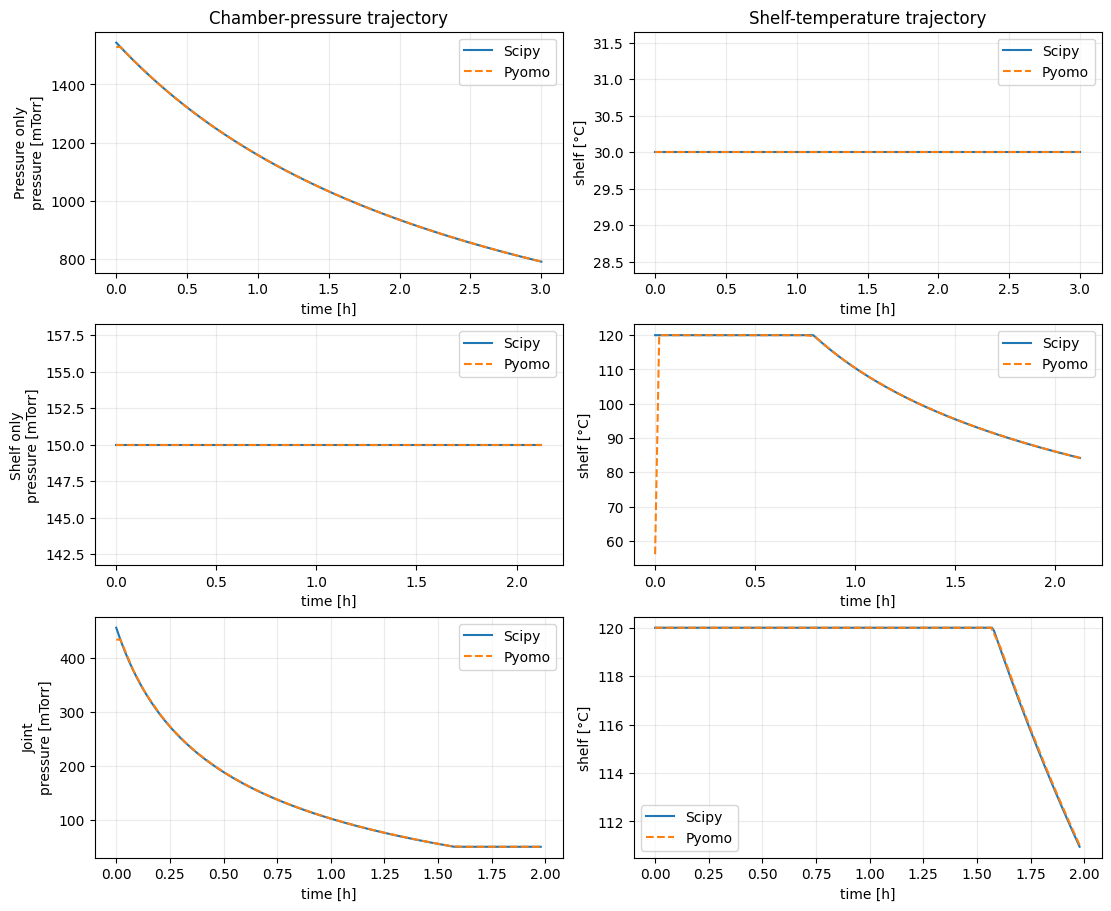

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(11, 9), layout="constrained")
for row, (label, runs) in enumerate(comparisons.items()):
    for backend, style in (("scipy", "-"), ("pyomo", "--")):
        table = runs[backend].trajectory
        axes[row, 0].plot(table[:, 0], table[:, 4], style, label=backend.capitalize())
        axes[row, 1].plot(table[:, 0], table[:, 3], style, label=backend.capitalize())
    axes[row, 0].set(ylabel=f"{label}\npressure [mTorr]")
    axes[row, 1].set(ylabel="shelf [°C]")
    for ax in axes[row]:
        ax.set_xlabel("time [h]")
        ax.grid(alpha=0.25)
        ax.legend()
axes[0, 0].set_title("Chamber-pressure trajectory")
axes[0, 1].set_title("Shelf-temperature trajectory")
plt.show()


## Capability comparison

| Capability | SciPy optimizer | Pyomo backend |
| --- | --- | --- |
| Pressure-only, shelf-only, and joint cases | Yes | Yes |
| Primary-drying calculation | Advances one time step at a time | Simultaneous trajectory model |
| Completion-time handling | Integrates until drying is complete | Free final time is a decision variable |
| Control coupling across time | Not available in the legacy optimizers | Initial values and adjacent-node rate limits in the joint DAE model |
| Discretization | User-selected time step | Backward finite difference or Radau collocation |
| Warm start from a legacy trajectory | Not applicable | Available |
| Solver diagnostics | Seven-column trajectory and warnings | Status, termination condition, violations, model size, iterations |
| Shadow prices for active limits | No | Available when the NLP solver exports multipliers |
| Parameter estimation, design-space, sensitivity, robust/scenario, and multi-vial model builders | Separate legacy tools or not available | Available as optional fixed-horizon Pyomo prototypes |
| Installation and API status | Default dependency; stable legacy API | Optional Pyomo/IPOPT stack; experimental API |

The equivalent paper cases should produce the same answer. Pyomo's advantage is the set of formulations that can be added around the same physics, not a different nominal drying time.


## Pyomo-only extension: actuator limits

The paper's joint optimum can move both controls immediately. The following solve starts from the paper's fixed-cycle setpoints (150 mTorr and 30 °C) and limits pressure to 0.05 Torr/h and shelf temperature to 30 °C/h (0.5 °C/min). These constraints link adjacent decisions, so there is no equivalent call in the legacy SciPy optimizer.


In [5]:
idealized = comparisons["Joint"]["pyomo"]
rate_limited = run_joint_pyomo(
    a1,
    kc,
    discretization="collocation",
    nfe=collocation_nfe,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
    initial_pressure=initial_pressure_torr,
    initial_shelf_temperature=initial_shelf_temperature_c,
    pressure_ramp_rate=pressure_ramp_rate_torr_hr,
    shelf_temperature_ramp_rate=shelf_temperature_ramp_rate_c_hr,
)
assert rate_limited.success

table = rate_limited.trajectory
time_steps = np.diff(table[:, 0])  # [h]
pressure_rates = np.abs(np.diff(table[:, 4]) / 1000.0) / time_steps  # [Torr/h]
shelf_rates = np.abs(np.diff(table[:, 3])) / time_steps  # [°C/h]
assert np.max(pressure_rates) <= pressure_ramp_rate_torr_hr + 1.0e-4
assert np.max(shelf_rates) <= shelf_temperature_ramp_rate_c_hr + 1.0e-4

penalty_hr = rate_limited.objective_time_hr - idealized.objective_time_hr
print(f"Idealized Pyomo joint case: {idealized.objective_time_hr:.3f} h")
print(f"Rate-limited Pyomo case:     {rate_limited.objective_time_hr:.3f} h")
print(f"Added drying time:           {penalty_hr:.3f} h")


Idealized Pyomo joint case: 1.982 h
Rate-limited Pyomo case:     2.828 h
Added drying time:           0.846 h


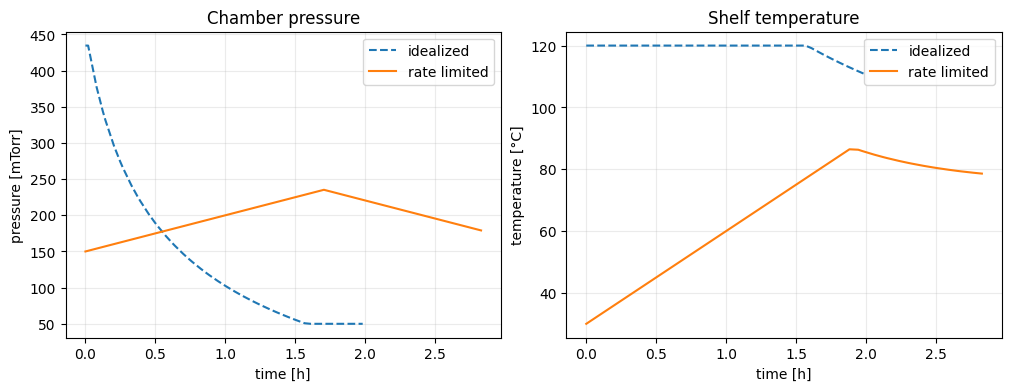


limit                                  shadow price        units
product_temperature_limit                  -0.12354         h/°C
equipment_capability                   -1.78511e-09     h/(kg/h)
chamber_pressure_lower_bound                0.13023       h/Torr
chamber_pressure_upper_bound           -1.70889e-09       h/Torr
shelf_temperature_lower_bound           2.98856e-12         h/°C
shelf_temperature_upper_bound           -0.00215607         h/°C


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
for label, run, style in (
    ("idealized", idealized, "--"),
    ("rate limited", rate_limited, "-"),
):
    table = run.trajectory
    axes[0].plot(table[:, 0], table[:, 4], style, label=label)
    axes[1].plot(table[:, 0], table[:, 3], style, label=label)
axes[0].set(title="Chamber pressure", xlabel="time [h]", ylabel="pressure [mTorr]")
axes[1].set(title="Shelf temperature", xlabel="time [h]", ylabel="temperature [°C]")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

shadow_units = {
    "product_temperature_limit": "h/°C",
    "equipment_capability": "h/(kg/h)",
    "chamber_pressure_lower_bound": "h/Torr",
    "chamber_pressure_upper_bound": "h/Torr",
    "shelf_temperature_lower_bound": "h/°C",
    "shelf_temperature_upper_bound": "h/°C",
}
print(f"\n{'limit':<36} {'shadow price':>14} {'units':>12}")
for name, value in idealized.shadow_prices.items():
    if name in shadow_units:
        print(f"{name:<36} {value:14.6g} {shadow_units[name]:>12}")


## Scope

This notebook uses the paper's mannitol example because all three optimizer modes are defined for the same physical case. The current results are close to the published times; small differences reflect current solver tolerances, exact terminal drying, and discretization.

The rate-limited model still uses quasi-steady product physics. It constrains the control sequence but does not model shelf, vial, or product thermal capacitance. A useful next backend step would be to combine the free-final-time DAE formulation with the existing robust/scenario and parameter-estimation prototypes, then add equipment thermal dynamics before treating rate-limited trajectories as controller-ready cycles.
